In [1]:
import sys
from pathlib import Path

def _find_project_root(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / ".git").exists():
            return p
    raise RuntimeError("Could not locate project root (no .git found above cwd)")

PROJECT_ROOT = _find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments" / "concept_drift"


# Concept Drift Detection on Synthetic Artifacts (HistGradientBoostingClassifier)

This notebook runs adjacent-year discrimination on synthetic artifacts generated in
`data drift testing on syntetic data.ipynb`, using a histogram-based gradient boosting
classifier (`sklearn.ensemble.HistGradientBoostingClassifier`) instead of the linear SGD
discriminator used in `concept_drift_detection_with_syntetic_data-disc.ipynb`. Tree-based
splits capture nonlinear decision boundaries, and the histogram binning this model uses is
built for exactly this data shape (millions of rows, a dozen or so low-dimensional continuous
features), so it trains far faster per year-pair than the MLP variant in
`concept_drift_detection_with_syntetic_data-MLP.ipynb`. The rest of the pipeline (manifest,
splits, checkpointing) is identical, so results are directly comparable across all three
notebooks.

Workflow summary:
- Load synthetic artifact manifest from `synthetic_drift_data/`
- Reuse train/val/test pixel splits from `data_split.npz`
- Run the same HistGradientBoostingClassifier discriminator pipeline for each artifact
- Organize execution by synthetic method type:
  - Mean/variance shift
  - Covariance shift
  - Noise injection

Each method section runs every `(mode, severity)` artifact available for that method — the
generator now sweeps a list of severity levels per method, so there are typically several
artifacts per mode, not one. Each is uniquely identified by `artifact_label` (method | mode |
severity) and results are grouped/plotted by severity to show a detection-power-vs-magnitude
curve rather than being averaged away.

A high ROC-AUC indicates stronger separability between adjacent years (drift signal).

If an artifact's metadata has `class_filter` set (concept-drift artifacts, where the
perturbation only touched pixels of one disturbance class), this notebook also reports AUC
restricted to that class's pixels (`*_auc_class_filtered`) alongside the whole-population AUC
— the whole-population number can understate a concept-drift signal that only affects a small
subset of pixels.

**Resumability:** every `(artifact, year-pair)` result is checkpointed to
`hgb_checkpoints_synthetic_drift/hgb_discriminator_results.pkl` as soon as it's computed.
If the kernel is interrupted or restarted, re-running the notebook picks up where it left off —
already-computed pairs print `CACHED: ...` and are not refit. Call `clear_results_checkpoint()`
if you change the modeling pipeline and want to force a full recompute.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score, roc_auc_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# Paths
split_path = str(PROJECT_ROOT / "data_split.npz")
manifest_json_path = PROJECT_ROOT / "synthetic_drift_data" / "synthetic_generation_manifest.json"
manifest_csv_path = PROJECT_ROOT / "synthetic_drift_data" / "synthetic_generation_manifest.csv"
original_data_path = str(PROJECT_ROOT / "training_data_with_features.zarr")  # unmodified source, used as a reference baseline

# Checkpointing (resumability): every (artifact, year-pair) result is persisted here as soon
# as it's computed, so an interrupted/restarted run can skip already-completed pairs.
CHECKPOINT_DIR = EXPERIMENTS_DIR / "hgb_checkpoints_synthetic_drift"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CHECKPOINT_PATH = CHECKPOINT_DIR / "hgb_discriminator_results.pkl"

# Runtime config
SAMPLE_FRACTION = 1.0  # Use 1.0 for full split, 0.1 for quick checks

# Load manifest (consume-only workflow)
if manifest_json_path.exists():
    with open(manifest_json_path, "r", encoding="utf-8") as handle:
        manifest_obj = json.load(handle)
    manifest_df = pd.DataFrame(manifest_obj.get("rows", []))
elif manifest_csv_path.exists():
    manifest_df = pd.read_csv(manifest_csv_path)
else:
    raise FileNotFoundError(
        "Synthetic manifest not found. Expected one of:\n"
        f"  - {manifest_json_path}\n"
        f"  - {manifest_csv_path}\n"
        "Generate artifacts first in 'data drift testing on syntetic data.ipynb'."
    )

required_cols = {"mode", "method", "zarr_path", "metadata_path"}
missing_cols = sorted(required_cols - set(manifest_df.columns))
if missing_cols:
    raise ValueError(f"Manifest is missing required columns: {missing_cols}")

if manifest_df.empty:
    raise ValueError("Manifest contains no artifact rows.")

manifest_df = manifest_df.copy()

# Older manifests (pre severity-sweep) won't have these columns; default them so the rest of
# this notebook can treat every manifest uniformly.
for optional_col, default_value in [("severity", None), ("pixel_fraction", 1.0), ("class_filter", None)]:
    if optional_col not in manifest_df.columns:
        manifest_df[optional_col] = default_value


def _severity_display(severity):
    """Render a severity value (dict for mean_variance_shift, scalar for others) as a short label."""
    if isinstance(severity, dict):
        return ", ".join(f"{k}={v}" for k, v in severity.items())
    if severity is None or (isinstance(severity, float) and np.isnan(severity)):
        return "n/a"
    return str(severity)


manifest_df["severity_display"] = manifest_df["severity"].apply(_severity_display)

# One artifact = one (method, mode, severity) combination now that the generator sweeps a
# severity list per method; the label must include severity or rows silently collide.
manifest_df["artifact_label"] = (
    manifest_df["method"] + " | " + manifest_df["mode"] + " | " + manifest_df["severity_display"]
)
manifest_df = manifest_df.sort_values(["method", "mode"]).reset_index(drop=True)

# Load data splits
splits = np.load(split_path)
train_pixel_indices = splits["train_pixel_indices"]
val_pixel_indices = splits["val_pixel_indices"]
test_pixel_indices = splits["test_pixel_indices"]

print(f"Loaded manifest rows: {len(manifest_df)}")
print(f"Split sizes: train={len(train_pixel_indices):,}, val={len(val_pixel_indices):,}, test={len(test_pixel_indices):,}")
display(manifest_df[["method", "mode", "severity_display", "pixel_fraction", "class_filter", "zarr_path", "metadata_path"]])

Loaded manifest rows: 18
Split sizes: train=5,597,776, val=1,273,437, test=1,283,992


,method,mode,severity_display,pixel_fraction,class_filter,zarr_path,metadata_path
0,covariance_shift,baseline_replication,0.05,1.0,1.0,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...
1,covariance_shift,baseline_replication,0.15,1.0,1.0,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...
2,covariance_shift,baseline_replication,0.3,1.0,1.0,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...
3,covariance_shift,per_year_original,0.05,1.0,1.0,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...
4,covariance_shift,per_year_original,0.15,1.0,1.0,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...
5,covariance_shift,per_year_original,0.3,1.0,1.0,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...
6,mean_variance_shift,baseline_replication,"mean_shift=0.0, variance_scale=1.15",1.0,NaN,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...
7,mean_variance_shift,baseline_replication,"mean_shift=0.1, variance_scale=1.0",1.0,NaN,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...
8,mean_variance_shift,baseline_replication,"mean_shift=0.1, variance_scale=1.15",1.0,NaN,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...
9,mean_variance_shift,per_year_original,"mean_shift=0.0, variance_scale=1.15",1.0,NaN,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...


In [4]:
# Manifest diagnostics
method_order = ["mean_variance_shift", "covariance_shift", "noise_injection"]
mode_order = ["baseline_replication", "per_year_original"]

summary_df = (
    manifest_df.groupby(["method", "mode"], dropna=False)
    .size()
    .rename("n_artifacts")
    .reset_index()
    .sort_values(["method", "mode"])
    .reset_index(drop=True)
)

display(summary_df)

detail_df = (
    manifest_df.groupby(["method", "mode", "severity_display"], dropna=False)
    .size()
    .rename("n_artifacts")
    .reset_index()
    .sort_values(["method", "mode", "severity_display"])
    .reset_index(drop=True)
)

display(detail_df)

def _resolve_manifest_path(p):
    p = Path(p)
    return p if p.is_absolute() else PROJECT_ROOT / p

missing_files = []
for _, row in manifest_df.iterrows():
    zarr_ok = _resolve_manifest_path(row["zarr_path"]).exists()
    meta_ok = _resolve_manifest_path(row["metadata_path"]).exists()
    if not (zarr_ok and meta_ok):
        missing_files.append({
            "method": row["method"],
            "mode": row["mode"],
            "severity_display": row["severity_display"],
            "zarr_exists": zarr_ok,
            "metadata_exists": meta_ok,
        })

if missing_files:
    missing_df = pd.DataFrame(missing_files)
    display(missing_df)
    raise FileNotFoundError("Some artifact files from manifest are missing.")

print("All manifest-referenced artifact files are present.")

,method,mode,n_artifacts
0,covariance_shift,baseline_replication,3
1,covariance_shift,per_year_original,3
2,mean_variance_shift,baseline_replication,3
3,mean_variance_shift,per_year_original,3
4,noise_injection,baseline_replication,3
5,noise_injection,per_year_original,3


,method,mode,severity_display,n_artifacts
0,covariance_shift,baseline_replication,0.05,1
1,covariance_shift,baseline_replication,0.15,1
2,covariance_shift,baseline_replication,0.3,1
3,covariance_shift,per_year_original,0.05,1
4,covariance_shift,per_year_original,0.15,1
5,covariance_shift,per_year_original,0.3,1
6,mean_variance_shift,baseline_replication,"mean_shift=0.0, variance_scale=1.15",1
7,mean_variance_shift,baseline_replication,"mean_shift=0.1, variance_scale=1.0",1
8,mean_variance_shift,baseline_replication,"mean_shift=0.1, variance_scale=1.15",1
9,mean_variance_shift,per_year_original,"mean_shift=0.0, variance_scale=1.15",1


All manifest-referenced artifact files are present.


In [5]:
RESULTS_CHECKPOINT_COLUMNS = [
    "method", "mode", "severity", "severity_display", "pixel_fraction", "class_filter",
    "artifact_label", "zarr_path", "pair", "year_t_minus_1", "year_t", "sample_fraction",
    "n_train", "n_val", "n_test", "val_auc", "test_auc", "val_auc_class_filtered",
    "test_auc_class_filtered", "val_f1", "test_f1", "time_sec", "changed_years",
    "perturb_year_values",
]


def load_results_checkpoint(path=RESULTS_CHECKPOINT_PATH):
    """Load the on-disk results checkpoint, or an empty frame with the expected schema."""
    if path.exists():
        return pd.read_pickle(path)
    return pd.DataFrame(columns=RESULTS_CHECKPOINT_COLUMNS)


def save_results_checkpoint(df, path=RESULTS_CHECKPOINT_PATH):
    """Write the results checkpoint atomically (tmp file + replace) so a crash mid-write can't corrupt it."""
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    df.to_pickle(tmp_path)
    tmp_path.replace(path)


def clear_results_checkpoint(path=RESULTS_CHECKPOINT_PATH):
    """Delete the on-disk checkpoint and reset the in-memory cache. Call this after changing the modeling pipeline."""
    global CHECKPOINT_DF
    if path.exists():
        path.unlink()
    CHECKPOINT_DF = pd.DataFrame(columns=RESULTS_CHECKPOINT_COLUMNS)
    print(f"Cleared results checkpoint at {path}")


def prepare_features_for_year(ds_subset, year_idx):
    """Prepare per-pixel features for a given year index using S2 bands only."""
    if year_idx == 0:
        return None, None

    valid_mask = ds_subset.disturbances[:, year_idx].values != 255

    s2_data = ds_subset.s2_bands.values  # shape (n_pixels, n_years, n_bands)
    s2_t = s2_data[:, year_idx, :].copy()  # shape (n_pixels, n_bands)

    # Vectorized NaN imputation: per-pixel, per-band mean across years
    nan_mask = np.isnan(s2_t)
    if np.any(nan_mask):
        band_means = np.nanmean(s2_data, axis=1)  # shape (n_pixels, n_bands)
        s2_t[nan_mask] = band_means[nan_mask]

    X = s2_t
    y = ds_subset.disturbances[:, year_idx].values

    # Combined mask: valid disturbance + binary label + finite features
    keep_mask = valid_mask & np.isin(y, [0, 1]) & np.all(np.isfinite(X), axis=1)
    X = X[keep_mask]
    y = y[keep_mask]

    if len(X) == 0:
        return None, None

    return X, y


def build_pair_dataset_cached(X_prev, y_prev, X_curr, y_curr):
    """Build binary year-pair dataset from pre-computed features.

    Returns (X_pair, pair_label, disturbance_label). pair_label is 0/1 for which year a row
    came from - the discriminator's actual training target. disturbance_label is the original
    0/1 disturbance class for that row, kept alongside so class-conditional AUC can be
    computed for concept-drift artifacts (class_filter != None) without retraining: the
    whole-population AUC can understate a shift that only touched one class's pixels.
    """
    if X_prev is None or X_curr is None:
        return None, None, None

    if X_prev.shape[1] != X_curr.shape[1]:
        return None, None, None

    X_pair = np.vstack([X_prev, X_curr])
    pair_label = np.concatenate([
        np.zeros(len(y_prev), dtype=np.uint8),
        np.ones(len(y_curr), dtype=np.uint8),
    ])
    disturbance_label = np.concatenate([y_prev, y_curr]).astype(np.uint8)

    return X_pair, pair_label, disturbance_label


def _sample_indices(indices, sample_fraction, rng_seed=RANDOM_STATE):
    if sample_fraction >= 1.0:
        return indices
    rng_local = np.random.default_rng(rng_seed)
    sample_size = max(1, int(len(indices) * sample_fraction))
    return rng_local.choice(indices, size=sample_size, replace=False)


def _class_conditional_auc(y_true, y_proba, disturbance_label, target_class):
    """AUC restricted to rows whose original disturbance label equals target_class.

    Returns NaN when there is no class filter, or when the restricted subset doesn't have
    both pair_label classes present (AUC is undefined there).
    """
    if target_class is None or disturbance_label is None:
        return np.nan
    mask = disturbance_label == target_class
    if mask.sum() < 2 or len(np.unique(y_true[mask])) < 2:
        return np.nan
    return float(roc_auc_score(y_true[mask], y_proba[mask]))


def to_auc_display(df, id_cols):
    """Trim a results dataframe down to identifying columns plus a single 'AUC' column (test AUC).

    Every table in this notebook displays test AUC only, under the name 'AUC' - val AUC,
    class-filtered AUC, and F1 stay in the underlying results_df for plotting but aren't
    shown in tables.
    """
    cols = [c for c in id_cols if c in df.columns] + ["test_auc"]
    return df[cols].rename(columns={"test_auc": "AUC"})


def plot_artifact_auc(results_df, title_suffix="", reference_auc=None):
    """Plot test AUC ('AUC') per year pair.

    reference_auc, when given, is a sequence aligned to results_df's rows - the
    original-unmodified-data AUC for the same year pairs - drawn as a dashed reference line
    so a per_year_original artifact's perturbed-pair results can be read against it.
    """
    if len(results_df) == 0:
        print("No rows to plot for this artifact.")
        return

    x = np.arange(len(results_df))
    plt.figure(figsize=(10, 4.5))
    plt.plot(x, results_df["test_auc"], marker="o", label="AUC")

    if reference_auc is not None:
        plt.plot(x, reference_auc, marker="d", linestyle="--", color="gray", label="AUC (original, unmodified)")

    plt.xticks(x, results_df["pair"], rotation=45, ha="right")
    plt.ylim(0.45, 1.0)
    plt.ylabel("ROC-AUC")
    plt.title(f"Adjacent-Year Drift Discriminator AUC{title_suffix}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def run_discriminator_on_dataset(
    zarr_path,
    method,
    mode,
    artifact_label,
    severity=None,
    severity_display=None,
    pixel_fraction=None,
    class_filter=None,
    changed_years=None,
    perturb_year_values=None,
    sample_fraction=SAMPLE_FRACTION,
):
    """Run the adjacent-year HistGradientBoostingClassifier discriminator pipeline against any zarr dataset.

    Shared by synthetic artifacts (via run_discriminator_for_artifact) and the unmodified
    original dataset (the per_year_original reference) so both paths train/evaluate exactly
    the same way.

    Resumability: each (artifact_label, pair, sample_fraction) result is looked up in the
    on-disk checkpoint (CHECKPOINT_DF) before doing any work for that pair. A hit skips
    feature prep and model fitting entirely; a miss computes the pair as before, then appends
    the new row to the checkpoint and saves it to disk immediately.
    """
    global CHECKPOINT_DF

    zarr_path = Path(zarr_path)
    if not zarr_path.is_absolute():
        zarr_path = PROJECT_ROOT / zarr_path

    ds_artifact = xr.open_zarr(zarr_path)
    year_values = ds_artifact.year.values
    n_years = len(year_values)
    n_pairs = n_years - 2

    train_sample = _sample_indices(train_pixel_indices, sample_fraction, rng_seed=RANDOM_STATE)
    val_sample = _sample_indices(val_pixel_indices, sample_fraction, rng_seed=RANDOM_STATE + 1)
    test_sample = _sample_indices(test_pixel_indices, sample_fraction, rng_seed=RANDOM_STATE + 2)

    ds_train = ds_artifact.isel(pixel=train_sample)
    ds_val = ds_artifact.isel(pixel=val_sample)
    ds_test = ds_artifact.isel(pixel=test_sample)

    print(f"Artifact: {artifact_label}")
    print(f"Dataset: {zarr_path}")
    print(f"Pairs to evaluate: {n_pairs}")

    results = []
    skipped_pairs = []
    start_time = time.time()

    for pair_idx, idx_curr in enumerate(range(2, n_years), start=1):
        idx_prev = idx_curr - 1
        year_prev = int(year_values[idx_prev])
        year_curr = int(year_values[idx_curr])
        pair_name = f"{year_prev} vs {year_curr}"

        pair_start = time.time()
        print(f"\n[{pair_idx}/{n_pairs}] {pair_name}")

        cache_hit = CHECKPOINT_DF[
            (CHECKPOINT_DF["artifact_label"] == artifact_label)
            & (CHECKPOINT_DF["pair"] == pair_name)
            & (CHECKPOINT_DF["sample_fraction"] == sample_fraction)
        ]
        if len(cache_hit) > 0:
            cached_row = cache_hit.iloc[-1].to_dict()
            results.append(cached_row)
            print(
                f"  CACHED: Val AUC = {cached_row['val_auc']:.4f} | Test AUC = {cached_row['test_auc']:.4f} "
                f"| Val F1 = {cached_row['val_f1']:.4f} | Test F1 = {cached_row['test_f1']:.4f}"
            )
            continue

        X_train_prev, y_train_prev = prepare_features_for_year(ds_train, idx_prev)
        X_train_curr, y_train_curr = prepare_features_for_year(ds_train, idx_curr)
        X_train, y_train, _ = build_pair_dataset_cached(X_train_prev, y_train_prev, X_train_curr, y_train_curr)

        X_val_prev, y_val_prev = prepare_features_for_year(ds_val, idx_prev)
        X_val_curr, y_val_curr = prepare_features_for_year(ds_val, idx_curr)
        X_val, y_val, disturbance_val = build_pair_dataset_cached(X_val_prev, y_val_prev, X_val_curr, y_val_curr)

        X_test_prev, y_test_prev = prepare_features_for_year(ds_test, idx_prev)
        X_test_curr, y_test_curr = prepare_features_for_year(ds_test, idx_curr)
        X_test, y_test, disturbance_test = build_pair_dataset_cached(X_test_prev, y_test_prev, X_test_curr, y_test_curr)

        if any(v is None for v in [X_train, y_train, X_val, y_val, X_test, y_test]):
            skipped_pairs.append((pair_name, "missing or invalid data after filtering"))
            print("  SKIP: missing data")
            continue

        if len(np.unique(y_train)) < 2 or len(np.unique(y_val)) < 2 or len(np.unique(y_test)) < 2:
            skipped_pairs.append((pair_name, "single class present in splits"))
            print("  SKIP: single class in one split")
            continue

        # HistGradientBoostingClassifier splits on raw feature values (histogram-binned
        # internally), so unlike the linear/MLP notebooks there's no StandardScaler step here.
        model = HistGradientBoostingClassifier(
            loss="log_loss",
            learning_rate=0.1,
            max_iter=200,
            max_leaf_nodes=31,
            l2_regularization=0.0,
            class_weight="balanced",
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10,
            random_state=RANDOM_STATE,
        )
        model.fit(X_train, y_train)

        val_proba = model.predict_proba(X_val)[:, 1]
        test_proba = model.predict_proba(X_test)[:, 1]

        val_auc = roc_auc_score(y_val, val_proba)
        test_auc = roc_auc_score(y_test, test_proba)
        val_pred = (val_proba >= 0.5).astype(int)
        test_pred = (test_proba >= 0.5).astype(int)
        val_f1 = f1_score(y_val, val_pred)
        test_f1 = f1_score(y_test, test_pred)

        val_auc_class_filtered = _class_conditional_auc(y_val, val_proba, disturbance_val, class_filter)
        test_auc_class_filtered = _class_conditional_auc(y_test, test_proba, disturbance_test, class_filter)

        pair_time = time.time() - pair_start

        row = {
            "method": method,
            "mode": mode,
            "severity": severity,
            "severity_display": severity_display,
            "pixel_fraction": pixel_fraction,
            "class_filter": class_filter,
            "artifact_label": artifact_label,
            "zarr_path": str(zarr_path),
            "pair": pair_name,
            "year_t_minus_1": year_prev,
            "year_t": year_curr,
            "sample_fraction": sample_fraction,
            "n_train": int(len(y_train)),
            "n_val": int(len(y_val)),
            "n_test": int(len(y_test)),
            "val_auc": float(val_auc),
            "test_auc": float(test_auc),
            "val_auc_class_filtered": val_auc_class_filtered,
            "test_auc_class_filtered": test_auc_class_filtered,
            "val_f1": float(val_f1),
            "test_f1": float(test_f1),
            "time_sec": float(pair_time),
            "changed_years": changed_years,
            "perturb_year_values": perturb_year_values,
        }
        results.append(row)

        CHECKPOINT_DF = pd.concat([CHECKPOINT_DF, pd.DataFrame([row])], ignore_index=True)
        save_results_checkpoint(CHECKPOINT_DF)

        auc_msg = (
            f"  RESULTS: Val AUC = {val_auc:.4f} | Test AUC = {test_auc:.4f} "
            f"| Val F1 = {val_f1:.4f} | Test F1 = {test_f1:.4f}"
        )
        if class_filter is not None:
            auc_msg += (
                f" | Val AUC[class={class_filter}] = {val_auc_class_filtered:.4f} "
                f"| Test AUC[class={class_filter}] = {test_auc_class_filtered:.4f}"
            )
        print(auc_msg)

    total_time = time.time() - start_time
    results_df = pd.DataFrame(results).sort_values("year_t").reset_index(drop=True)

    print("\n" + "=" * 70)
    print(f"COMPLETE: {artifact_label}")
    print(f"Elapsed: {total_time:.1f}s ({total_time/60:.1f}m)")
    if len(results_df) > 0:
        print(f"Pairs trained: {len(results_df)}")
        print(f"Average time per pair: {results_df['time_sec'].mean():.1f}s")
        print(f"Min/Max AUC (test): {results_df['test_auc'].min():.3f} / {results_df['test_auc'].max():.3f}")
    else:
        print("No valid year pairs were found.")
    print("=" * 70 + "\n")

    return results_df, skipped_pairs


def run_discriminator_for_artifact(artifact_row, sample_fraction=SAMPLE_FRACTION):
    """Run the adjacent-year discriminator pipeline for a single synthetic artifact row."""
    artifact_row = artifact_row.copy()

    metadata_path = Path(artifact_row["metadata_path"])
    if not metadata_path.is_absolute():
        metadata_path = PROJECT_ROOT / metadata_path
    with open(metadata_path, "r", encoding="utf-8") as handle:
        metadata = json.load(handle)

    return run_discriminator_on_dataset(
        zarr_path=artifact_row["zarr_path"],
        method=str(artifact_row["method"]),
        mode=str(artifact_row["mode"]),
        artifact_label=str(artifact_row["artifact_label"]),
        severity=metadata.get("severity"),
        severity_display=artifact_row.get("severity_display"),
        pixel_fraction=metadata.get("pixel_fraction"),
        class_filter=metadata.get("class_filter"),
        changed_years=metadata.get("changed_years"),
        perturb_year_values=metadata.get("perturb_year_values"),
        sample_fraction=sample_fraction,
    )


def run_method_section(method_name, sample_fraction=SAMPLE_FRACTION):
    """Run every (mode, severity) artifact for one synthetic method and return section outputs."""
    section_rows = manifest_df[manifest_df["method"] == method_name].copy()
    if section_rows.empty:
        print(f"No artifacts found for method: {method_name}")
        return {"method": method_name, "artifacts": {}, "combined": pd.DataFrame()}

    mode_rank = {"baseline_replication": 0, "per_year_original": 1}
    section_rows["_mode_rank"] = section_rows["mode"].map(mode_rank).fillna(99)
    # Stable sort preserves each mode's original severity-sweep order from the manifest.
    section_rows = section_rows.sort_values(["_mode_rank", "mode"], kind="stable").reset_index(drop=True)

    artifact_outputs = {}
    combined_frames = []

    for _, row in section_rows.iterrows():
        artifact_label = row["artifact_label"]
        print(f"\n### Running artifact: {artifact_label}")
        results_df, skipped_pairs = run_discriminator_for_artifact(row, sample_fraction=sample_fraction)

        # Keyed by artifact_label (mode + severity), not mode alone: with the severity sweep
        # there are now multiple rows per mode, and keying by mode alone would silently
        # overwrite all but the last severity level's results.
        artifact_outputs[artifact_label] = {
            "results_df": results_df,
            "skipped_pairs": skipped_pairs,
            "row": row.to_dict(),
        }

        if len(results_df) > 0:
            display_df = to_auc_display(results_df, ["pair", "year_t_minus_1", "year_t"])
            reference_auc = None
            if row["mode"] == "per_year_original" and original_reference_df is not None:
                # Reference is joined per year pair (not a single scalar) since natural
                # year-to-year AUC can vary pair to pair even with no perturbation at all.
                reference_cols = original_reference_df[["year_t_minus_1", "year_t", "AUC"]].rename(
                    columns={"AUC": "AUC (original, unmodified)"}
                )
                display_df = display_df.merge(reference_cols, on=["year_t_minus_1", "year_t"], how="left")
                reference_auc = display_df["AUC (original, unmodified)"]
            display(display_df)
            plot_artifact_auc(results_df, title_suffix=f" | {artifact_label}", reference_auc=reference_auc)
            combined_frames.append(results_df)

        if skipped_pairs:
            print("Skipped pairs:")
            for pair_name, reason in skipped_pairs:
                print(f"  - {pair_name}: {reason}")

    if combined_frames:
        combined = pd.concat(combined_frames, ignore_index=True)
    else:
        combined = pd.DataFrame()

    return {
        "method": method_name,
        "artifacts": artifact_outputs,
        "combined": combined,
    }


def summarize_and_plot_section(combined_df, method_name):
    """Severity-aware summary table + detection-power-vs-severity plot, shared by every method section."""
    if combined_df.empty:
        print(f"No results to summarize for {method_name}.")
        return pd.DataFrame()

    summary = (
        combined_df.groupby(["mode", "severity_display"], as_index=False, sort=False)
        .agg(
            mean_test_auc=("test_auc", "mean"),
            n_pairs=("pair", "count"),
        )
    )
    print(f"{method_name} combined view:")
    display_summary = summary.rename(columns={"mean_test_auc": "AUC"})
    is_pyo = display_summary["mode"] == "per_year_original"
    if original_reference_mean_auc is not None and is_pyo.any():
        display_summary.loc[is_pyo, "AUC (original, unmodified)"] = original_reference_mean_auc
    display(display_summary)

    plt.figure(figsize=(10, 4.5))
    for mode, mode_df in summary.groupby("mode", sort=False):
        plt.plot(mode_df["severity_display"], mode_df["mean_test_auc"], marker="o", label=f"{mode} (AUC)")
    if original_reference_mean_auc is not None and (summary["mode"] == "per_year_original").any():
        plt.axhline(
            original_reference_mean_auc, color="gray", linestyle="--",
            label="AUC (original, unmodified)",
        )
    plt.ylabel("Mean AUC across year pairs")
    plt.xlabel("Severity level")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0.45, 1.0)
    plt.title(f"{method_name}: detection power vs. severity")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return summary

In [6]:
# Global container for section outputs
section_results = {}
original_reference_df = None
original_reference_mean_auc = None

# Resumability: load any previously-computed (artifact, pair) results from disk. Cells below
# will skip recomputing anything already present here.
CHECKPOINT_DF = load_results_checkpoint()
print(f"Loaded {len(CHECKPOINT_DF)} cached (artifact, pair) result(s) from {RESULTS_CHECKPOINT_PATH}")

print("Ready. Run the original-data reference cell, then the method sections below.")

Loaded 35 cached (artifact, pair) result(s) from c:\Users\bartu\Desktop\Fonda-scikit - Git\experiments\concept_drift\hgb_checkpoints_synthetic_drift\hgb_discriminator_results.pkl
Ready. Run the original-data reference cell, then the method sections below.


## Original (Unmodified) Reference

Run the same adjacent-year discriminator directly on `training_data_with_features.zarr`,
with no synthetic perturbation applied at all. `per_year_original` mode keeps every year's
real data and only perturbs two of them, so most of its year pairs already reflect natural
year-to-year variation rather than an injected shift. This reference AUC (per pair, and its
mean) is joined into every `per_year_original` table below so perturbed results can be read
against the unperturbed baseline instead of in isolation.

In [7]:
original_results_df, original_skipped_pairs = run_discriminator_on_dataset(
    zarr_path=original_data_path,
    method="none",
    mode="original_unmodified",
    artifact_label="original_unmodified",
    sample_fraction=SAMPLE_FRACTION,
)

original_reference_df = to_auc_display(original_results_df, ["pair", "year_t_minus_1", "year_t"])
original_reference_mean_auc = (
    float(original_reference_df["AUC"].mean()) if len(original_reference_df) > 0 else None
)

print("Original (unmodified) reference AUC per year pair:")
display(original_reference_df)
if original_reference_mean_auc is not None:
    print(f"Mean reference AUC across pairs: {original_reference_mean_auc:.4f}")

Artifact: original_unmodified
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\training_data_with_features.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  CACHED: Val AUC = 0.7357 | Test AUC = 0.7347 | Val F1 = 0.6856 | Test F1 = 0.6893

[2/5] 2018 vs 2019
  CACHED: Val AUC = 0.7864 | Test AUC = 0.7873 | Val F1 = 0.7071 | Test F1 = 0.7075

[3/5] 2019 vs 2020
  CACHED: Val AUC = 0.6015 | Test AUC = 0.5954 | Val F1 = 0.5680 | Test F1 = 0.5619

[4/5] 2020 vs 2021
  CACHED: Val AUC = 0.6221 | Test AUC = 0.6252 | Val F1 = 0.5328 | Test F1 = 0.5415

[5/5] 2021 vs 2022
  CACHED: Val AUC = 0.7067 | Test AUC = 0.7112 | Val F1 = 0.6604 | Test F1 = 0.6615

COMPLETE: original_unmodified
Elapsed: 0.0s (0.0m)
Pairs trained: 5
Average time per pair: 191.4s
Min/Max AUC (test): 0.595 / 0.787

Original (unmodified) reference AUC per year pair:


,pair,year_t_minus_1,year_t,AUC
0,2017 vs 2018,2017,2018,0.734700
1,2018 vs 2019,2018,2019,0.787270
2,2019 vs 2020,2019,2020,0.595409
3,2020 vs 2021,2020,2021,0.625182
4,2021 vs 2022,2021,2022,0.711245


Mean reference AUC across pairs: 0.6908


## Mean/Variance Shift

Run discriminator on synthetic artifacts generated with `mean_variance_shift` for both modes.

In [8]:
print("=== Mean/Variance Shift ===")
print("Running discriminator for mean_variance_shift artifacts...")

=== Mean/Variance Shift ===
Running discriminator for mean_variance_shift artifacts...



### Running artifact: mean_variance_shift | baseline_replication | mean_shift=0.0, variance_scale=1.15
Artifact: mean_variance_shift | baseline_replication | mean_shift=0.0, variance_scale=1.15
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-mean_variance_shift_severity-mean_shift0.0-variance_scale1.15_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.7102 | Test AUC = 0.7134 | Val F1 = 0.5883 | Test F1 = 0.5815

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.7117 | Test AUC = 0.7147 | Val F1 = 0.6818 | Test F1 = 0.6905

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.5686 | Test F1 = 0.5685

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.7102 | Test AUC = 0.7134 | Val F1 = 0.5883 | Test F1 = 0.5815

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.7117 | Test AUC = 0.7147 | Val F1 = 0.6818 | Test F1 = 0.6905

COMPLETE: m

,pair,year_t_minus_1,year_t,AUC
0,2017 vs 2018,2017,2018,0.713409
1,2018 vs 2019,2018,2019,0.714673
2,2019 vs 2020,2019,2020,0.500000
3,2020 vs 2021,2020,2021,0.713409
4,2021 vs 2022,2021,2022,0.714673


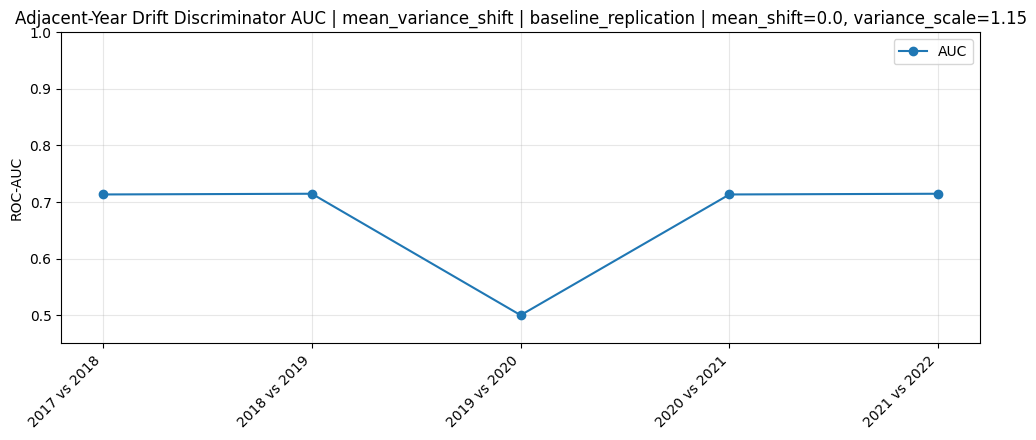


### Running artifact: mean_variance_shift | baseline_replication | mean_shift=0.1, variance_scale=1.0
Artifact: mean_variance_shift | baseline_replication | mean_shift=0.1, variance_scale=1.0
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-mean_variance_shift_severity-mean_shift0.1-variance_scale1.0_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.9598 | Test AUC = 0.9601 | Val F1 = 0.8913 | Test F1 = 0.8936

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.9599 | Test AUC = 0.9603 | Val F1 = 0.8885 | Test F1 = 0.8899

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.5686 | Test F1 = 0.5685

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.9598 | Test AUC = 0.9601 | Val F1 = 0.8913 | Test F1 = 0.8936

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.9599 | Test AUC = 0.9603 | Val F1 = 0.8885 | Test F1 = 0.8899

COMPLETE: mean

,pair,year_t_minus_1,year_t,AUC
0,2017 vs 2018,2017,2018,0.960104
1,2018 vs 2019,2018,2019,0.960258
2,2019 vs 2020,2019,2020,0.500000
3,2020 vs 2021,2020,2021,0.960104
4,2021 vs 2022,2021,2022,0.960258


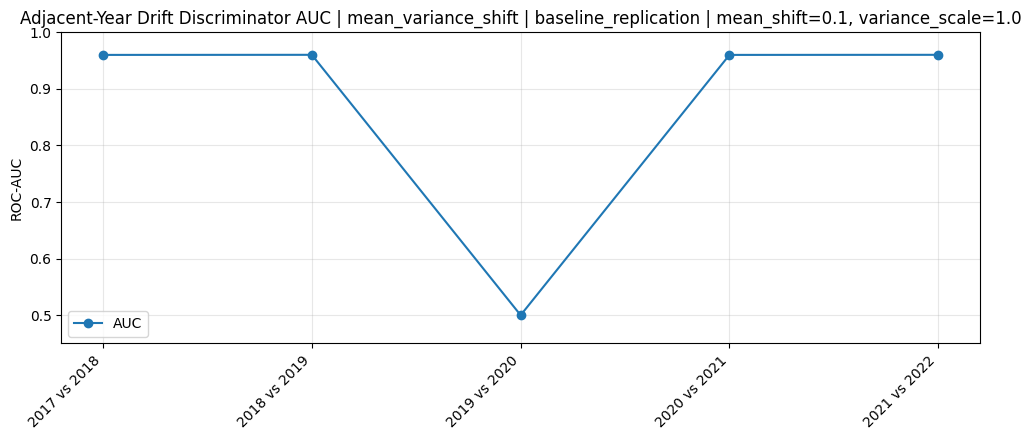


### Running artifact: mean_variance_shift | baseline_replication | mean_shift=0.1, variance_scale=1.15
Artifact: mean_variance_shift | baseline_replication | mean_shift=0.1, variance_scale=1.15
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-mean_variance_shift_severity-mean_shift0.1-variance_scale1.15_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.9360 | Test AUC = 0.9356 | Val F1 = 0.8571 | Test F1 = 0.8602

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.9359 | Test AUC = 0.9355 | Val F1 = 0.8626 | Test F1 = 0.8627

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.5686 | Test F1 = 0.5685

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.9360 | Test AUC = 0.9356 | Val F1 = 0.8571 | Test F1 = 0.8602

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.9359 | Test AUC = 0.9355 | Val F1 = 0.8626 | Test F1 = 0.8627

COMPLETE: m

,pair,year_t_minus_1,year_t,AUC
0,2017 vs 2018,2017,2018,0.935647
1,2018 vs 2019,2018,2019,0.935462
2,2019 vs 2020,2019,2020,0.500000
3,2020 vs 2021,2020,2021,0.935647
4,2021 vs 2022,2021,2022,0.935462


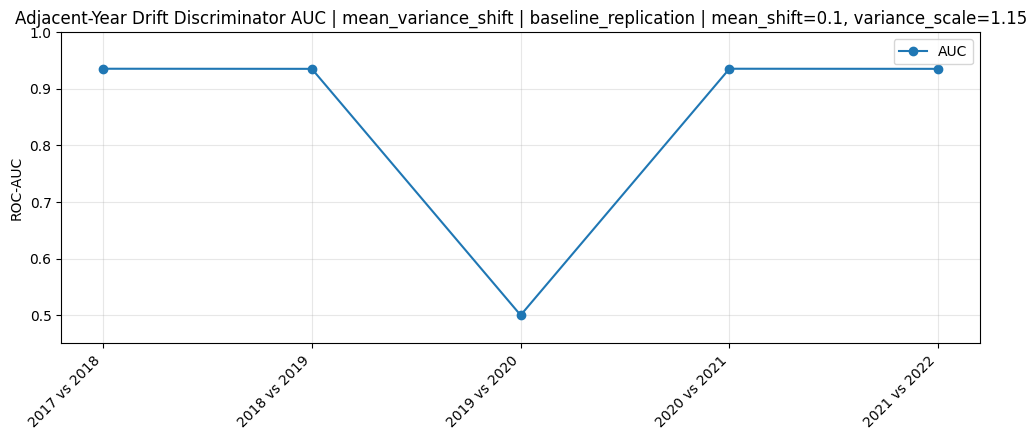


### Running artifact: mean_variance_shift | per_year_original | mean_shift=0.0, variance_scale=1.15
Artifact: mean_variance_shift | per_year_original | mean_shift=0.0, variance_scale=1.15
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-mean_variance_shift_severity-mean_shift0.0-variance_scale1.15_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.8148 | Test AUC = 0.8103 | Val F1 = 0.7373 | Test F1 = 0.7347

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.8428 | Test AUC = 0.8393 | Val F1 = 0.7537 | Test F1 = 0.7510

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.6021 | Test AUC = 0.5957 | Val F1 = 0.5700 | Test F1 = 0.5638

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.7523 | Test AUC = 0.7562 | Val F1 = 0.6585 | Test F1 = 0.6619

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.7981 | Test AUC = 0.7996 | Val F1 = 0.7236 | Test F1 = 0.7256

COMPLETE: mean_variance_shift | per_y

,pair,year_t_minus_1,year_t,AUC,"AUC (original, unmodified)"
0,2017 vs 2018,2017,2018,0.810315,0.734700
1,2018 vs 2019,2018,2019,0.839318,0.787270
2,2019 vs 2020,2019,2020,0.595711,0.595409
3,2020 vs 2021,2020,2021,0.756227,0.625182
4,2021 vs 2022,2021,2022,0.799637,0.711245


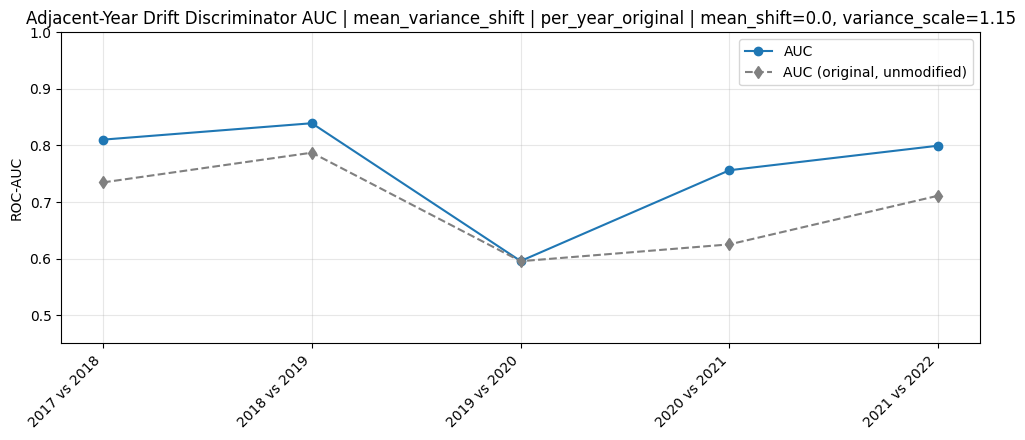


### Running artifact: mean_variance_shift | per_year_original | mean_shift=0.1, variance_scale=1.0
Artifact: mean_variance_shift | per_year_original | mean_shift=0.1, variance_scale=1.0
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-mean_variance_shift_severity-mean_shift0.1-variance_scale1.0_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.9384 | Test AUC = 0.9348 | Val F1 = 0.8644 | Test F1 = 0.8618

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.9482 | Test AUC = 0.9496 | Val F1 = 0.8733 | Test F1 = 0.8728

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.6022 | Test AUC = 0.5958 | Val F1 = 0.5705 | Test F1 = 0.5643

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.9594 | Test AUC = 0.9618 | Val F1 = 0.8939 | Test F1 = 0.8967

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.9511 | Test AUC = 0.9538 | Val F1 = 0.8748 | Test F1 = 0.8771

COMPLETE: mean_variance_shift | per_year

,pair,year_t_minus_1,year_t,AUC,"AUC (original, unmodified)"
0,2017 vs 2018,2017,2018,0.934795,0.734700
1,2018 vs 2019,2018,2019,0.949605,0.787270
2,2019 vs 2020,2019,2020,0.595779,0.595409
3,2020 vs 2021,2020,2021,0.961769,0.625182
4,2021 vs 2022,2021,2022,0.953798,0.711245


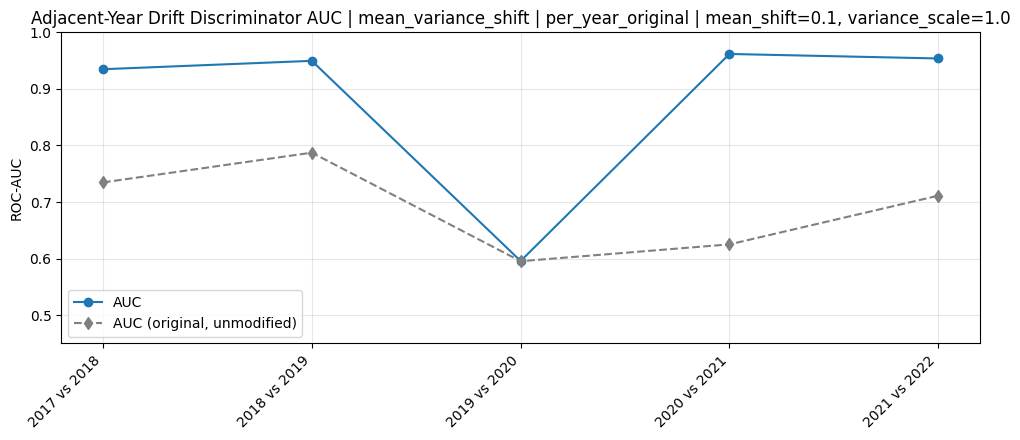


### Running artifact: mean_variance_shift | per_year_original | mean_shift=0.1, variance_scale=1.15
Artifact: mean_variance_shift | per_year_original | mean_shift=0.1, variance_scale=1.15
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-mean_variance_shift_severity-mean_shift0.1-variance_scale1.15_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.9090 | Test AUC = 0.9066 | Val F1 = 0.8285 | Test F1 = 0.8286

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.9268 | Test AUC = 0.9303 | Val F1 = 0.8505 | Test F1 = 0.8526

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.6021 | Test AUC = 0.5958 | Val F1 = 0.5699 | Test F1 = 0.5640

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.9312 | Test AUC = 0.9329 | Val F1 = 0.8540 | Test F1 = 0.8565

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.9199 | Test AUC = 0.9242 | Val F1 = 0.8453 | Test F1 = 0.8463

COMPLETE: mean_variance_shift | per_y

,pair,year_t_minus_1,year_t,AUC,"AUC (original, unmodified)"
0,2017 vs 2018,2017,2018,0.906621,0.734700
1,2018 vs 2019,2018,2019,0.930332,0.787270
2,2019 vs 2020,2019,2020,0.595818,0.595409
3,2020 vs 2021,2020,2021,0.932850,0.625182
4,2021 vs 2022,2021,2022,0.924163,0.711245


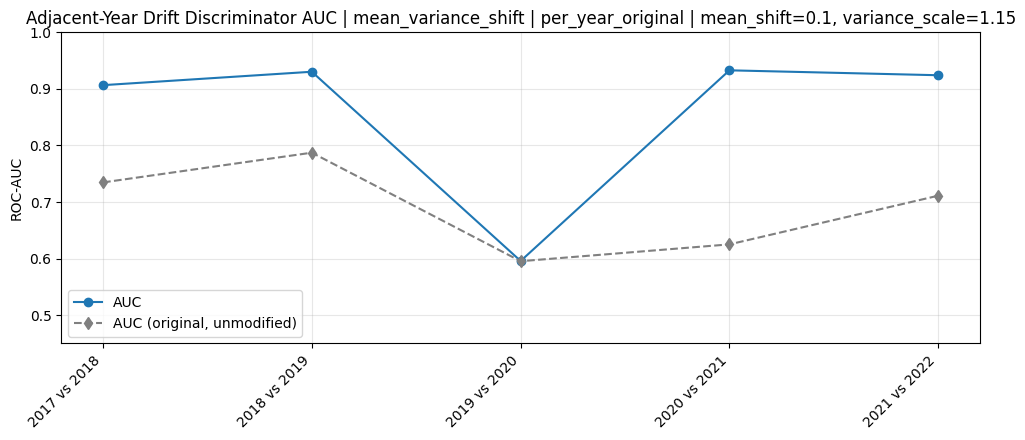

mean_variance_shift combined view:


,mode,severity_display,AUC,n_pairs,"AUC (original, unmodified)"
0,baseline_replication,"mean_shift=0.0, variance_scale=1.15",0.671233,5,NaN
1,baseline_replication,"mean_shift=0.1, variance_scale=1.0",0.868145,5,NaN
2,baseline_replication,"mean_shift=0.1, variance_scale=1.15",0.848443,5,NaN
3,per_year_original,"mean_shift=0.0, variance_scale=1.15",0.760242,5,0.690761
4,per_year_original,"mean_shift=0.1, variance_scale=1.0",0.879149,5,0.690761
5,per_year_original,"mean_shift=0.1, variance_scale=1.15",0.857957,5,0.690761


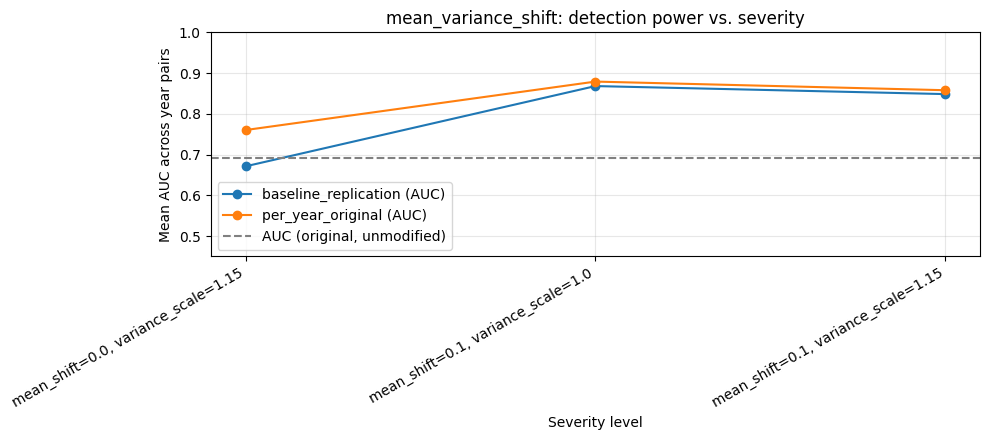

In [9]:
section_results["mean_variance_shift"] = run_method_section(
    method_name="mean_variance_shift",
    sample_fraction=SAMPLE_FRACTION,
 )

mean_combined = section_results["mean_variance_shift"]["combined"]
mean_summary = summarize_and_plot_section(mean_combined, "mean_variance_shift")

## Covariance Shift

Run discriminator on synthetic artifacts generated with `covariance_shift` for both modes.


### Running artifact: covariance_shift | baseline_replication | 0.05
Artifact: covariance_shift | baseline_replication | 0.05
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-covariance_shift_severity-0.05_class-1_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.5098 | Test AUC = 0.5095 | Val F1 = 0.4162 | Test F1 = 0.4174 | Val AUC[class=1] = 0.8179 | Test AUC[class=1] = 0.8032

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.5097 | Test AUC = 0.5094 | Val F1 = 0.5779 | Test F1 = 0.5780 | Val AUC[class=1] = 0.8211 | Test AUC[class=1] = 0.7722

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.5686 | Test F1 = 0.5685 | Val AUC[class=1] = 0.4991 | Test AUC[class=1] = 0.5252

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.5033 | Test AUC = 0.5036 | Val F1 = 0.4868 | Test F1 = 0.4869 | Val AUC[class=1] = 0.7300 | Test AU

,pair,year_t_minus_1,year_t,AUC
0,2017 vs 2018,2017,2018,0.509509
1,2018 vs 2019,2018,2019,0.509434
2,2019 vs 2020,2019,2020,0.500000
3,2020 vs 2021,2020,2021,0.503602
4,2021 vs 2022,2021,2022,0.503113


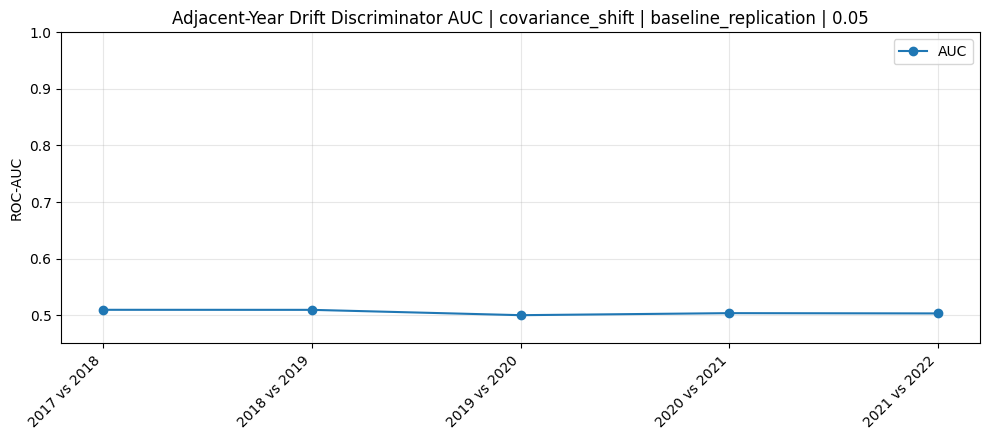


### Running artifact: covariance_shift | baseline_replication | 0.15
Artifact: covariance_shift | baseline_replication | 0.15
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-covariance_shift_severity-0.15_class-1_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.5170 | Test AUC = 0.5170 | Val F1 = 0.2798 | Test F1 = 0.2722 | Val AUC[class=1] = 0.9859 | Test AUC[class=1] = 0.9840

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.5170 | Test AUC = 0.5170 | Val F1 = 0.6329 | Test F1 = 0.6345 | Val AUC[class=1] = 0.9830 | Test AUC[class=1] = 0.9750

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.5686 | Test F1 = 0.5685 | Val AUC[class=1] = 0.4991 | Test AUC[class=1] = 0.5252

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.5079 | Test AUC = 0.5093 | Val F1 = 0.2412 | Test F1 = 0.2398 | Val AUC[class=1] = 0.9825 | Test AU

,pair,year_t_minus_1,year_t,AUC
0,2017 vs 2018,2017,2018,0.517010
1,2018 vs 2019,2018,2019,0.516989
2,2019 vs 2020,2019,2020,0.500000
3,2020 vs 2021,2020,2021,0.509301
4,2021 vs 2022,2021,2022,0.509083


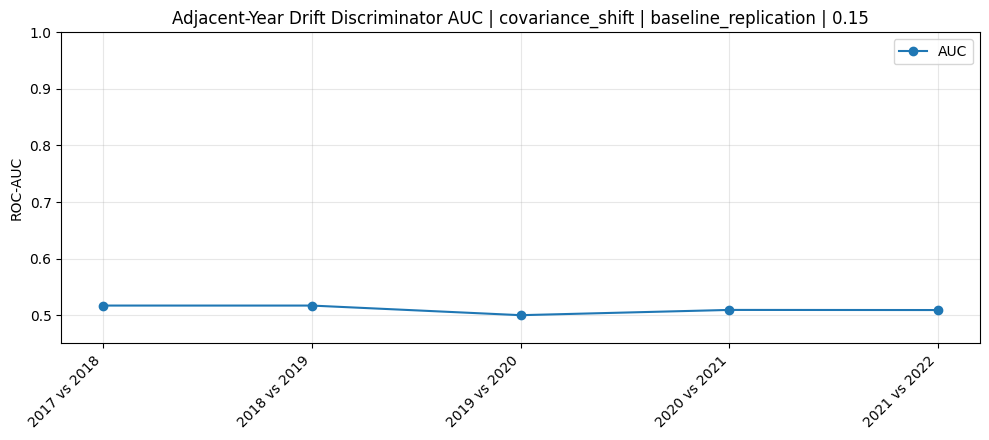


### Running artifact: covariance_shift | baseline_replication | 0.3
Artifact: covariance_shift | baseline_replication | 0.3
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-covariance_shift_severity-0.3_class-1_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.5183 | Test AUC = 0.5182 | Val F1 = 0.1690 | Test F1 = 0.1598 | Val AUC[class=1] = 0.9994 | Test AUC[class=1] = 0.9994

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.5182 | Test AUC = 0.5182 | Val F1 = 0.6535 | Test F1 = 0.6560 | Val AUC[class=1] = 0.9989 | Test AUC[class=1] = 0.9987

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.5686 | Test F1 = 0.5685 | Val AUC[class=1] = 0.4991 | Test AUC[class=1] = 0.5252

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.5089 | Test AUC = 0.5105 | Val F1 = 0.0913 | Test F1 = 0.0913 | Val AUC[class=1] = 0.9985 | Test AUC[c

,pair,year_t_minus_1,year_t,AUC
0,2017 vs 2018,2017,2018,0.518212
1,2018 vs 2019,2018,2019,0.518188
2,2019 vs 2020,2019,2020,0.500000
3,2020 vs 2021,2020,2021,0.510550
4,2021 vs 2022,2021,2022,0.510412


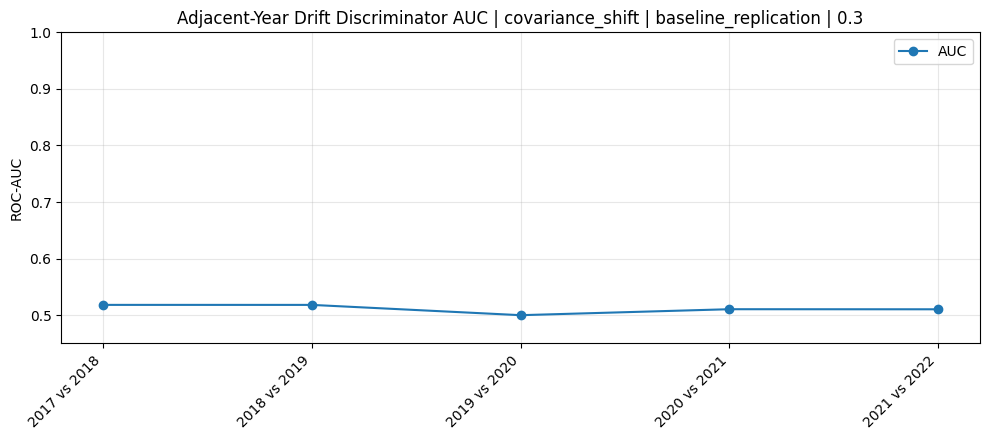


### Running artifact: covariance_shift | per_year_original | 0.05
Artifact: covariance_shift | per_year_original | 0.05
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-covariance_shift_severity-0.05_class-1_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.7398 | Test AUC = 0.7391 | Val F1 = 0.6887 | Test F1 = 0.6933 | Val AUC[class=1] = 0.8450 | Test AUC[class=1] = 0.8337

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.7890 | Test AUC = 0.7895 | Val F1 = 0.7095 | Test F1 = 0.7093 | Val AUC[class=1] = 0.8471 | Test AUC[class=1] = 0.8362

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.6020 | Test AUC = 0.5958 | Val F1 = 0.5700 | Test F1 = 0.5642 | Val AUC[class=1] = 0.5123 | Test AUC[class=1] = 0.5864

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.6242 | Test AUC = 0.6276 | Val F1 = 0.5396 | Test F1 = 0.5509 | Val AUC[class=1] = 0.7314 | Test AUC[class=1] = 0.7613

[5/5]

,pair,year_t_minus_1,year_t,AUC,"AUC (original, unmodified)"
0,2017 vs 2018,2017,2018,0.739081,0.734700
1,2018 vs 2019,2018,2019,0.789478,0.787270
2,2019 vs 2020,2019,2020,0.595799,0.595409
3,2020 vs 2021,2020,2021,0.627560,0.625182
4,2021 vs 2022,2021,2022,0.712512,0.711245


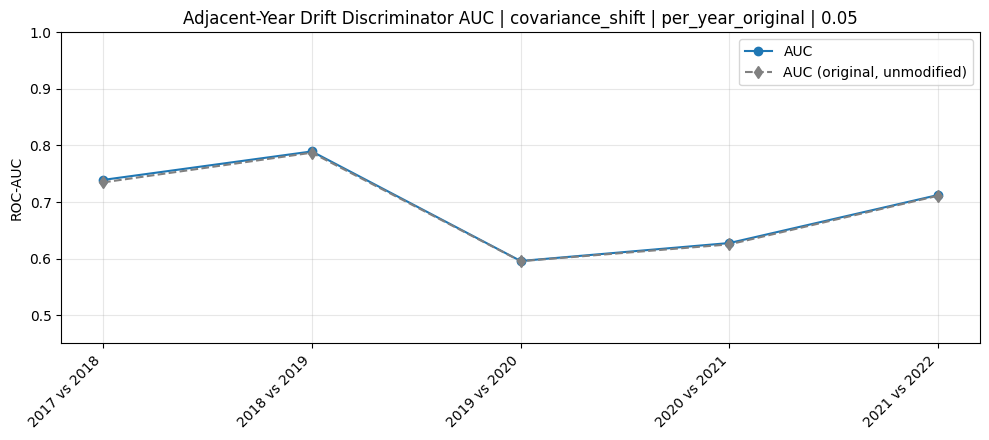


### Running artifact: covariance_shift | per_year_original | 0.15
Artifact: covariance_shift | per_year_original | 0.15
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-covariance_shift_severity-0.15_class-1_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.7426 | Test AUC = 0.7420 | Val F1 = 0.6883 | Test F1 = 0.6926 | Val AUC[class=1] = 0.9655 | Test AUC[class=1] = 0.9658

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.7913 | Test AUC = 0.7920 | Val F1 = 0.7121 | Test F1 = 0.7126 | Val AUC[class=1] = 0.9709 | Test AUC[class=1] = 0.9631

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.6021 | Test AUC = 0.5955 | Val F1 = 0.5704 | Test F1 = 0.5639 | Val AUC[class=1] = 0.5100 | Test AUC[class=1] = 0.5852

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.6264 | Test AUC = 0.6310 | Val F1 = 0.5421 | Test F1 = 0.5539 | Val AUC[class=1] = 0.9569 | Test AUC[class=1] = 0.9596

[5/5]

,pair,year_t_minus_1,year_t,AUC,"AUC (original, unmodified)"
0,2017 vs 2018,2017,2018,0.742034,0.734700
1,2018 vs 2019,2018,2019,0.792017,0.787270
2,2019 vs 2020,2019,2020,0.595486,0.595409
3,2020 vs 2021,2020,2021,0.630960,0.625182
4,2021 vs 2022,2021,2022,0.715597,0.711245


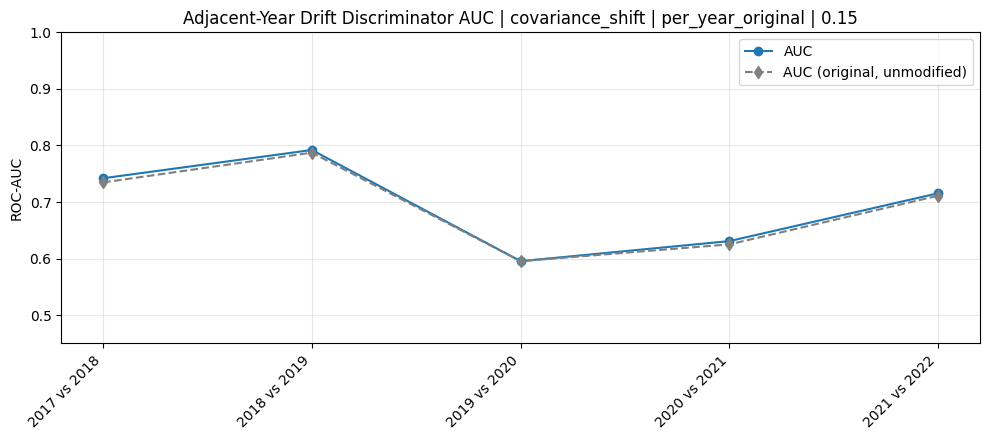


### Running artifact: covariance_shift | per_year_original | 0.3
Artifact: covariance_shift | per_year_original | 0.3
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-covariance_shift_severity-0.3_class-1_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.7429 | Test AUC = 0.7425 | Val F1 = 0.6871 | Test F1 = 0.6911 | Val AUC[class=1] = 0.9933 | Test AUC[class=1] = 0.9918

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.7913 | Test AUC = 0.7928 | Val F1 = 0.7123 | Test F1 = 0.7139 | Val AUC[class=1] = 0.9951 | Test AUC[class=1] = 0.9912

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.6021 | Test AUC = 0.5958 | Val F1 = 0.5710 | Test F1 = 0.5648 | Val AUC[class=1] = 0.5100 | Test AUC[class=1] = 0.5845

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.6282 | Test AUC = 0.6328 | Val F1 = 0.5361 | Test F1 = 0.5463 | Val AUC[class=1] = 0.9958 | Test AUC[class=1] = 0.9962

[5/5] 20

,pair,year_t_minus_1,year_t,AUC,"AUC (original, unmodified)"
0,2017 vs 2018,2017,2018,0.742522,0.734700
1,2018 vs 2019,2018,2019,0.792794,0.787270
2,2019 vs 2020,2019,2020,0.595826,0.595409
3,2020 vs 2021,2020,2021,0.632795,0.625182
4,2021 vs 2022,2021,2022,0.716967,0.711245


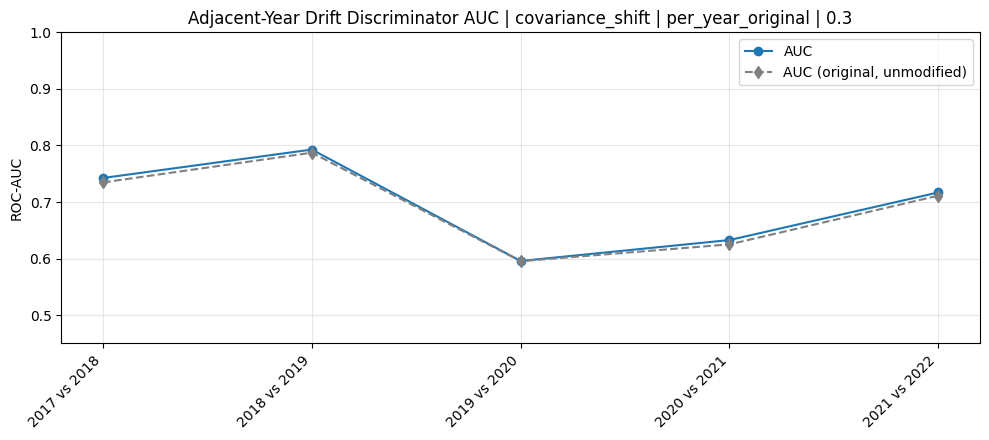

covariance_shift combined view:


,mode,severity_display,AUC,n_pairs,"AUC (original, unmodified)"
0,baseline_replication,0.05,0.505131,5,NaN
1,baseline_replication,0.15,0.510476,5,NaN
2,baseline_replication,0.3,0.511472,5,NaN
3,per_year_original,0.05,0.692886,5,0.690761
4,per_year_original,0.15,0.695219,5,0.690761
5,per_year_original,0.3,0.696181,5,0.690761


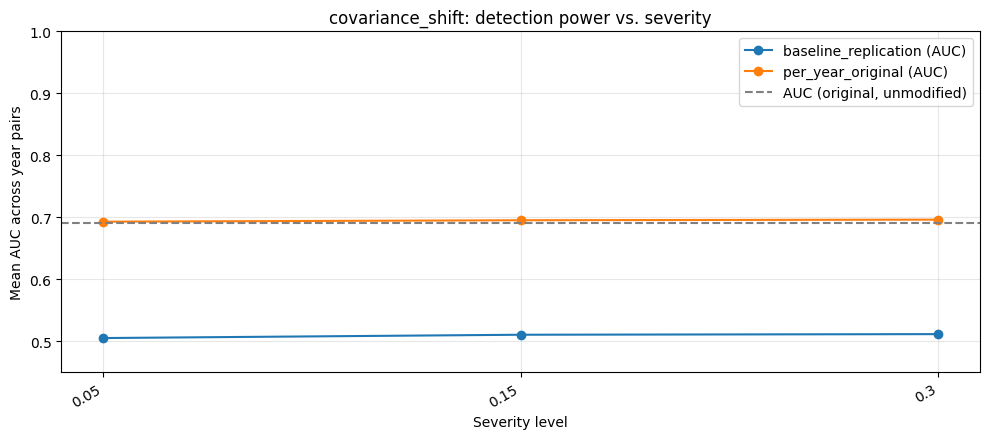

In [10]:
section_results["covariance_shift"] = run_method_section(
    method_name="covariance_shift",
    sample_fraction=SAMPLE_FRACTION,
 )

cov_combined = section_results["covariance_shift"]["combined"]
cov_summary = summarize_and_plot_section(cov_combined, "covariance_shift")

## Noise Injection

Run discriminator on synthetic artifacts generated with `noise_injection` for both modes.


### Running artifact: noise_injection | baseline_replication | 0.04
Artifact: noise_injection | baseline_replication | 0.04
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-noise_injection_severity-0.04_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  CACHED: Val AUC = 0.6503 | Test AUC = 0.6517 | Val F1 = 0.5862 | Test F1 = 0.5875

[2/5] 2018 vs 2019
  CACHED: Val AUC = 0.6444 | Test AUC = 0.6444 | Val F1 = 0.6152 | Test F1 = 0.6161

[3/5] 2019 vs 2020
  CACHED: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.5686 | Test F1 = 0.5685

[4/5] 2020 vs 2021
  CACHED: Val AUC = 0.6535 | Test AUC = 0.6538 | Val F1 = 0.5922 | Test F1 = 0.5925

[5/5] 2021 vs 2022
  CACHED: Val AUC = 0.6443 | Test AUC = 0.6447 | Val F1 = 0.6154 | Test F1 = 0.6161

COMPLETE: noise_injection | baseline_replication | 0.04
Elapsed: 0.0s (0.0m)
Pairs trained: 5
Average time per pair: 1

,pair,year_t_minus_1,year_t,AUC
0,2017 vs 2018,2017,2018,0.651742
1,2018 vs 2019,2018,2019,0.644356
2,2019 vs 2020,2019,2020,0.500000
3,2020 vs 2021,2020,2021,0.653830
4,2021 vs 2022,2021,2022,0.644680


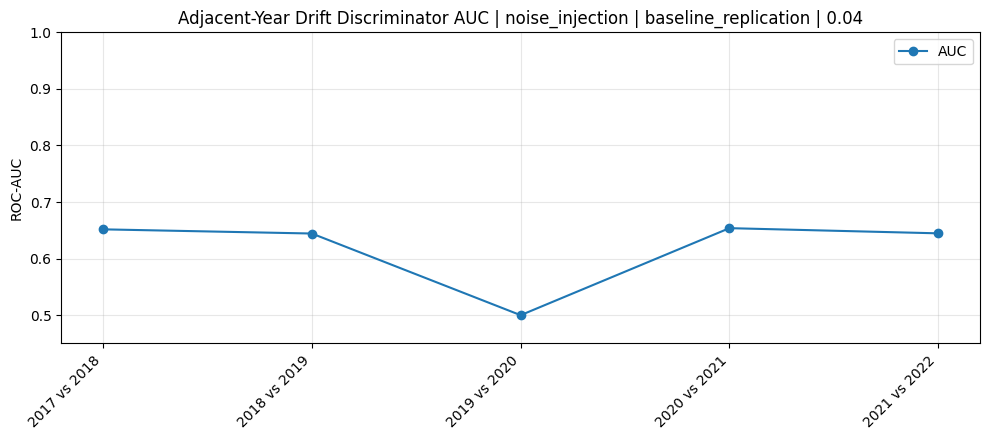


### Running artifact: noise_injection | baseline_replication | 0.08
Artifact: noise_injection | baseline_replication | 0.08
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-noise_injection_severity-0.08_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  CACHED: Val AUC = 0.7604 | Test AUC = 0.7636 | Val F1 = 0.6522 | Test F1 = 0.6560

[2/5] 2018 vs 2019
  CACHED: Val AUC = 0.7587 | Test AUC = 0.7619 | Val F1 = 0.7234 | Test F1 = 0.7254

[3/5] 2019 vs 2020
  CACHED: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.5686 | Test F1 = 0.5685

[4/5] 2020 vs 2021
  CACHED: Val AUC = 0.7590 | Test AUC = 0.7615 | Val F1 = 0.6527 | Test F1 = 0.6561

[5/5] 2021 vs 2022
  CACHED: Val AUC = 0.7610 | Test AUC = 0.7643 | Val F1 = 0.7253 | Test F1 = 0.7277

COMPLETE: noise_injection | baseline_replication | 0.08
Elapsed: 0.0s (0.0m)
Pairs trained: 5
Average time per pair: 1

,pair,year_t_minus_1,year_t,AUC
0,2017 vs 2018,2017,2018,0.763600
1,2018 vs 2019,2018,2019,0.761862
2,2019 vs 2020,2019,2020,0.500000
3,2020 vs 2021,2020,2021,0.761513
4,2021 vs 2022,2021,2022,0.764321


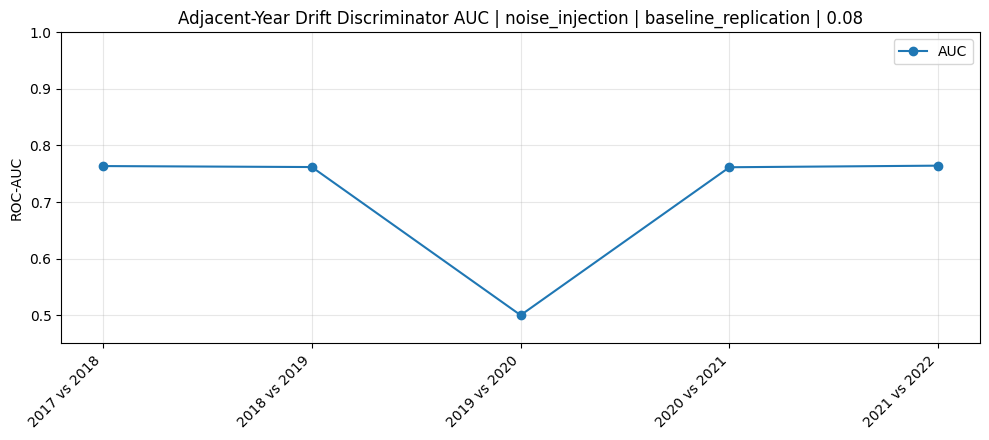


### Running artifact: noise_injection | baseline_replication | 0.16
Artifact: noise_injection | baseline_replication | 0.16
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-noise_injection_severity-0.16_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  CACHED: Val AUC = 0.8907 | Test AUC = 0.8953 | Val F1 = 0.7927 | Test F1 = 0.7985

[2/5] 2018 vs 2019
  CACHED: Val AUC = 0.8850 | Test AUC = 0.8891 | Val F1 = 0.8255 | Test F1 = 0.8304

[3/5] 2019 vs 2020
  CACHED: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.5686 | Test F1 = 0.5685

[4/5] 2020 vs 2021
  CACHED: Val AUC = 0.8896 | Test AUC = 0.8936 | Val F1 = 0.7927 | Test F1 = 0.7975

[5/5] 2021 vs 2022
  CACHED: Val AUC = 0.8888 | Test AUC = 0.8913 | Val F1 = 0.8287 | Test F1 = 0.8316

COMPLETE: noise_injection | baseline_replication | 0.16
Elapsed: 0.0s (0.0m)
Pairs trained: 5
Average time per pair: 1

,pair,year_t_minus_1,year_t,AUC
0,2017 vs 2018,2017,2018,0.895279
1,2018 vs 2019,2018,2019,0.889144
2,2019 vs 2020,2019,2020,0.500000
3,2020 vs 2021,2020,2021,0.893582
4,2021 vs 2022,2021,2022,0.891262


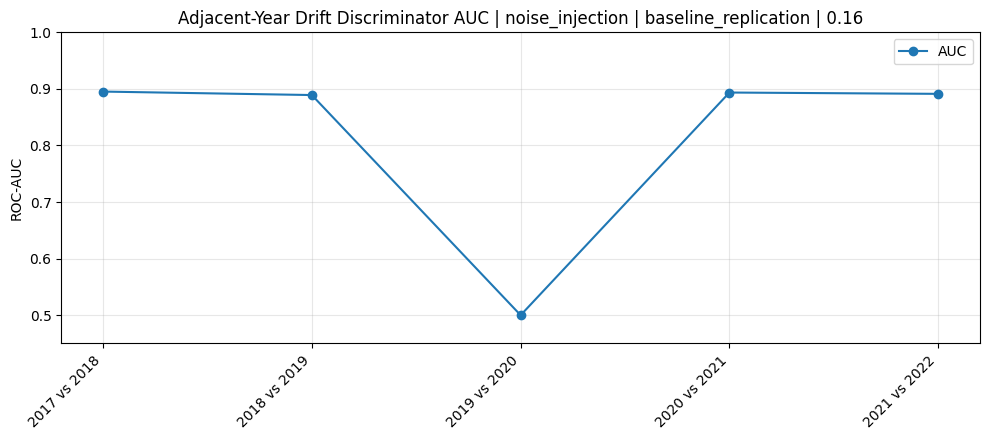


### Running artifact: noise_injection | per_year_original | 0.04
Artifact: noise_injection | per_year_original | 0.04
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-noise_injection_severity-0.04_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  CACHED: Val AUC = 0.7531 | Test AUC = 0.7533 | Val F1 = 0.6881 | Test F1 = 0.6929

[2/5] 2018 vs 2019
  CACHED: Val AUC = 0.7978 | Test AUC = 0.7976 | Val F1 = 0.7203 | Test F1 = 0.7183

[3/5] 2019 vs 2020
  CACHED: Val AUC = 0.6018 | Test AUC = 0.5956 | Val F1 = 0.5694 | Test F1 = 0.5627

[4/5] 2020 vs 2021
  CACHED: Val AUC = 0.6764 | Test AUC = 0.6785 | Val F1 = 0.5967 | Test F1 = 0.6025

[5/5] 2021 vs 2022
  CACHED: Val AUC = 0.7383 | Test AUC = 0.7434 | Val F1 = 0.6894 | Test F1 = 0.6922

COMPLETE: noise_injection | per_year_original | 0.04
Elapsed: 0.0s (0.0m)
Pairs trained: 5
Average time per pair: 169.6s
Min/Max AUC (test): 0.5

,pair,year_t_minus_1,year_t,AUC,"AUC (original, unmodified)"
0,2017 vs 2018,2017,2018,0.753290,0.734700
1,2018 vs 2019,2018,2019,0.797647,0.787270
2,2019 vs 2020,2019,2020,0.595608,0.595409
3,2020 vs 2021,2020,2021,0.678548,0.625182
4,2021 vs 2022,2021,2022,0.743396,0.711245


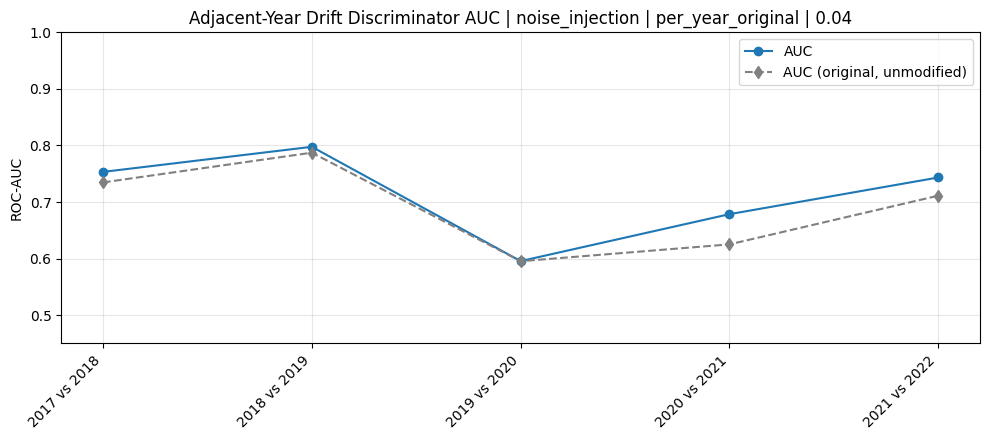


### Running artifact: noise_injection | per_year_original | 0.08
Artifact: noise_injection | per_year_original | 0.08
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-noise_injection_severity-0.08_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  CACHED: Val AUC = 0.7839 | Test AUC = 0.7870 | Val F1 = 0.7028 | Test F1 = 0.7093

[2/5] 2018 vs 2019
  CACHED: Val AUC = 0.8251 | Test AUC = 0.8245 | Val F1 = 0.7535 | Test F1 = 0.7508

[3/5] 2019 vs 2020
  CACHED: Val AUC = 0.6017 | Test AUC = 0.5954 | Val F1 = 0.5697 | Test F1 = 0.5638

[4/5] 2020 vs 2021
  CACHED: Val AUC = 0.7566 | Test AUC = 0.7636 | Val F1 = 0.6615 | Test F1 = 0.6723

[5/5] 2021 vs 2022
  CACHED: Val AUC = 0.7812 | Test AUC = 0.7865 | Val F1 = 0.7273 | Test F1 = 0.7309

COMPLETE: noise_injection | per_year_original | 0.08
Elapsed: 0.0s (0.0m)
Pairs trained: 5
Average time per pair: 161.9s
Min/Max AUC (test): 0.5

,pair,year_t_minus_1,year_t,AUC,"AUC (original, unmodified)"
0,2017 vs 2018,2017,2018,0.786995,0.734700
1,2018 vs 2019,2018,2019,0.824515,0.787270
2,2019 vs 2020,2019,2020,0.595426,0.595409
3,2020 vs 2021,2020,2021,0.763559,0.625182
4,2021 vs 2022,2021,2022,0.786459,0.711245


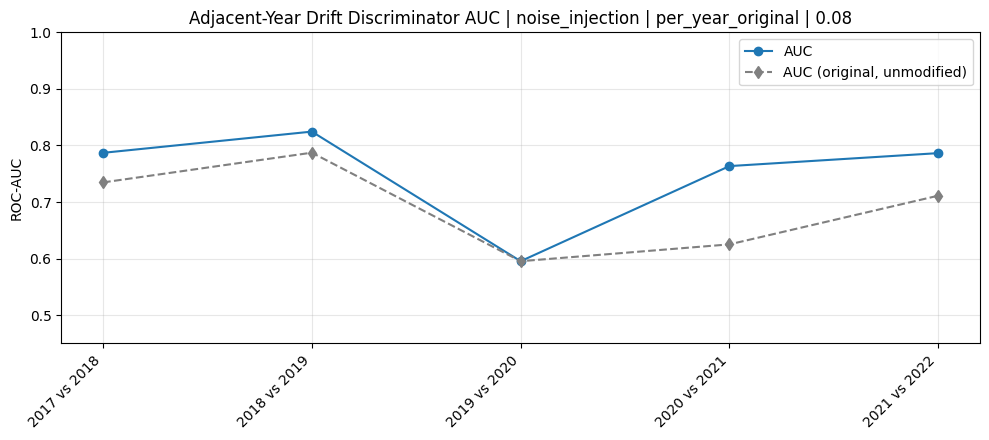


### Running artifact: noise_injection | per_year_original | 0.16
Artifact: noise_injection | per_year_original | 0.16
Dataset: c:\Users\bartu\Desktop\Fonda-scikit - Git\synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-noise_injection_severity-0.16_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  CACHED: Val AUC = 0.8838 | Test AUC = 0.8882 | Val F1 = 0.7907 | Test F1 = 0.7971

[2/5] 2018 vs 2019
  CACHED: Val AUC = 0.8978 | Test AUC = 0.8952 | Val F1 = 0.8315 | Test F1 = 0.8261

[3/5] 2019 vs 2020
  CACHED: Val AUC = 0.6019 | Test AUC = 0.5958 | Val F1 = 0.5702 | Test F1 = 0.5642

[4/5] 2020 vs 2021
  CACHED: Val AUC = 0.8997 | Test AUC = 0.9058 | Val F1 = 0.8072 | Test F1 = 0.8156

[5/5] 2021 vs 2022
  CACHED: Val AUC = 0.9029 | Test AUC = 0.9054 | Val F1 = 0.8348 | Test F1 = 0.8375

COMPLETE: noise_injection | per_year_original | 0.16
Elapsed: 0.0s (0.0m)
Pairs trained: 5
Average time per pair: 151.6s
Min/Max AUC (test): 0.5

,pair,year_t_minus_1,year_t,AUC,"AUC (original, unmodified)"
0,2017 vs 2018,2017,2018,0.888208,0.734700
1,2018 vs 2019,2018,2019,0.895213,0.787270
2,2019 vs 2020,2019,2020,0.595811,0.595409
3,2020 vs 2021,2020,2021,0.905841,0.625182
4,2021 vs 2022,2021,2022,0.905442,0.711245


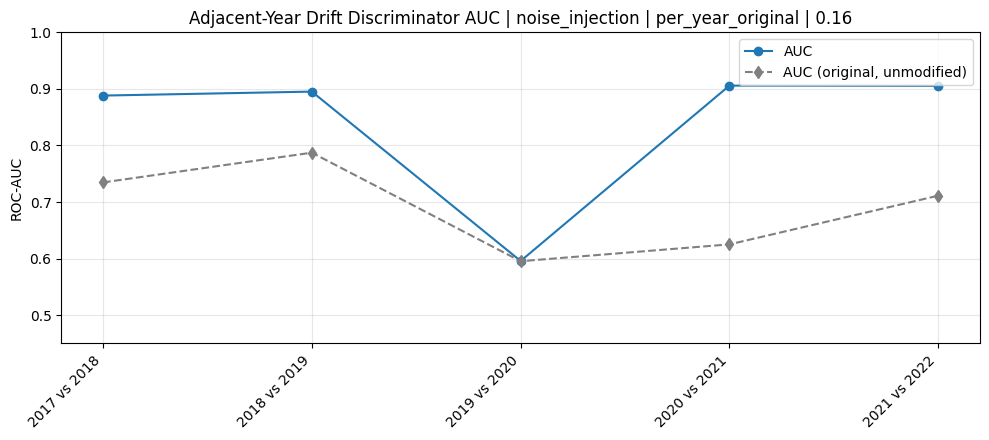

noise_injection combined view:


,mode,severity_display,AUC,n_pairs,"AUC (original, unmodified)"
0,baseline_replication,0.04,0.618922,5,NaN
1,baseline_replication,0.08,0.710259,5,NaN
2,baseline_replication,0.16,0.813854,5,NaN
3,per_year_original,0.04,0.713698,5,0.690761
4,per_year_original,0.08,0.751391,5,0.690761
5,per_year_original,0.16,0.838103,5,0.690761


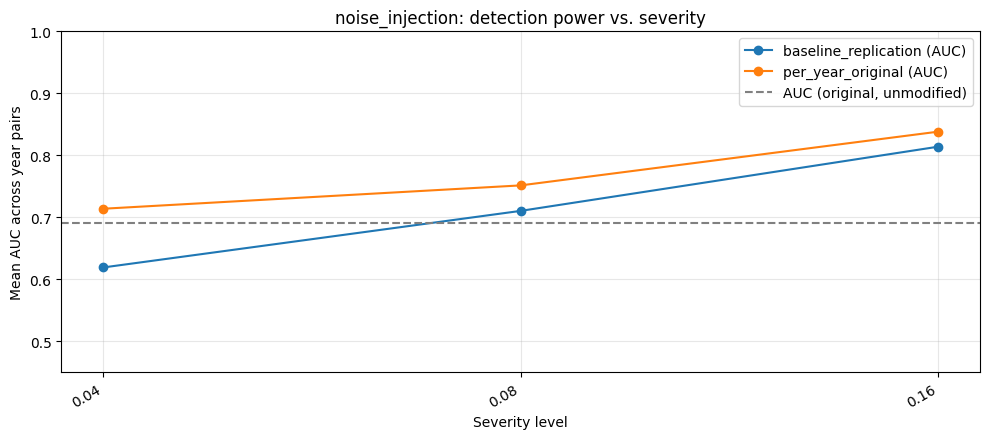

In [11]:
section_results["noise_injection"] = run_method_section(
    method_name="noise_injection",
    sample_fraction=SAMPLE_FRACTION,
 )

noise_combined = section_results["noise_injection"]["combined"]
noise_summary = summarize_and_plot_section(noise_combined, "noise_injection")

## Cross-Method Summary

Consolidate all method runs into one comparison table and aggregate chart.

Collected rows: 90


,method,mode,severity_display,pair,year_t_minus_1,year_t,AUC
0,mean_variance_shift,baseline_replication,"mean_shift=0.0, variance_scale=1.15",2017 vs 2018,2017,2018,0.713409
1,mean_variance_shift,baseline_replication,"mean_shift=0.0, variance_scale=1.15",2018 vs 2019,2018,2019,0.714673
2,mean_variance_shift,baseline_replication,"mean_shift=0.0, variance_scale=1.15",2019 vs 2020,2019,2020,0.500000
3,mean_variance_shift,baseline_replication,"mean_shift=0.0, variance_scale=1.15",2020 vs 2021,2020,2021,0.713409
4,mean_variance_shift,baseline_replication,"mean_shift=0.0, variance_scale=1.15",2021 vs 2022,2021,2022,0.714673


Method/mode/severity summary:


,method,mode,severity_display,AUC,n_pairs,"AUC (original, unmodified)"
0,covariance_shift,baseline_replication,0.05,0.505131,5,NaN
1,covariance_shift,baseline_replication,0.15,0.510476,5,NaN
2,covariance_shift,baseline_replication,0.3,0.511472,5,NaN
3,covariance_shift,per_year_original,0.05,0.692886,5,0.690761
4,covariance_shift,per_year_original,0.15,0.695219,5,0.690761
5,covariance_shift,per_year_original,0.3,0.696181,5,0.690761
6,mean_variance_shift,baseline_replication,"mean_shift=0.0, variance_scale=1.15",0.671233,5,NaN
7,mean_variance_shift,baseline_replication,"mean_shift=0.1, variance_scale=1.0",0.868145,5,NaN
8,mean_variance_shift,baseline_replication,"mean_shift=0.1, variance_scale=1.15",0.848443,5,NaN
9,mean_variance_shift,per_year_original,"mean_shift=0.0, variance_scale=1.15",0.760242,5,0.690761


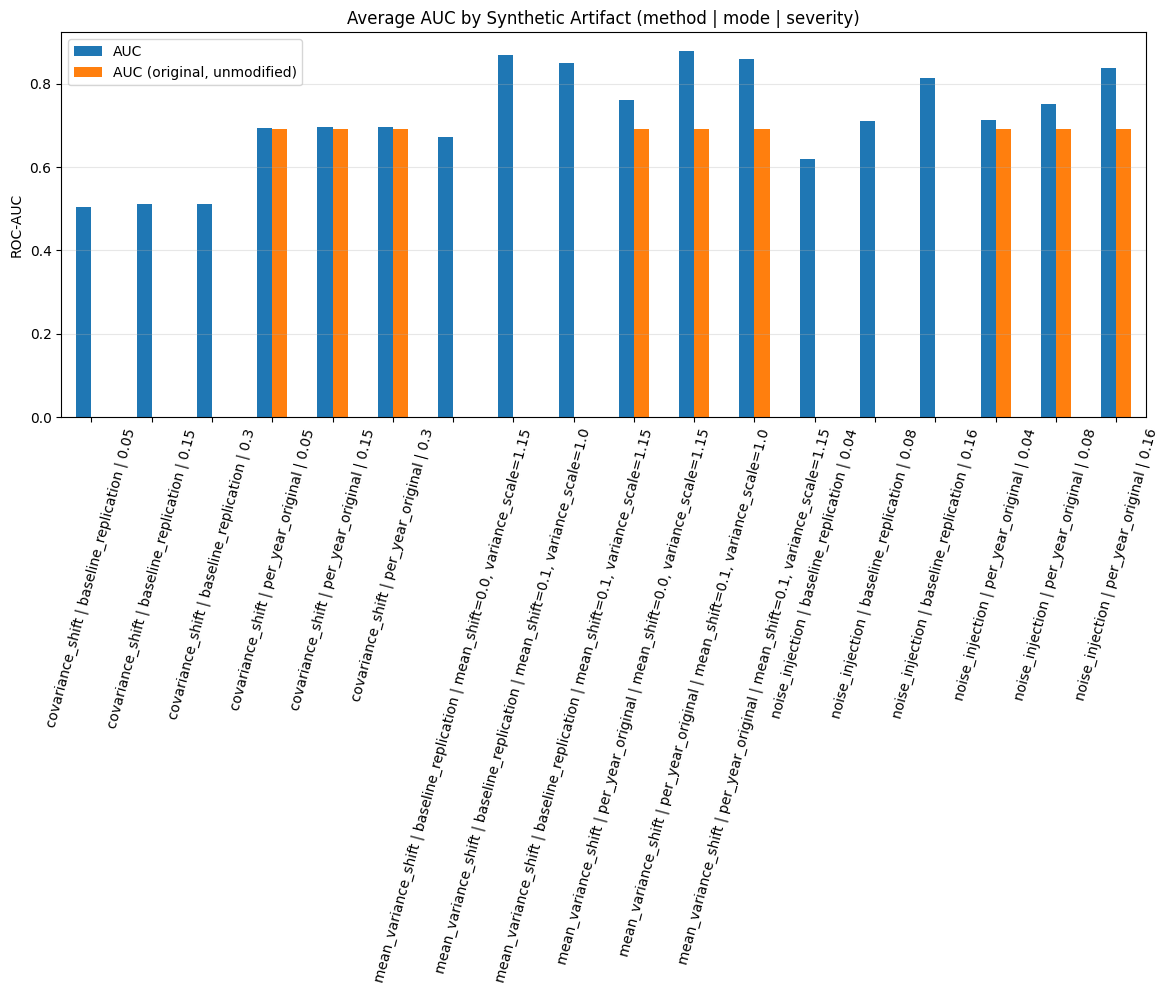

In [12]:
available = {
    k: v for k, v in section_results.items()
    if isinstance(v, dict) and not v.get("combined", pd.DataFrame()).empty
}

if not available:
    print("No method results available yet. Run the method section cells first.")
else:
    all_results = pd.concat([v["combined"] for v in available.values()], ignore_index=True)
    print(f"Collected rows: {len(all_results)}")
    display(
        to_auc_display(
            all_results, ["method", "mode", "severity_display", "pair", "year_t_minus_1", "year_t"]
        ).head()
    )

    summary = (
        all_results.groupby(["method", "mode", "severity_display"], as_index=False, sort=False)
        .agg(
            mean_test_auc=("test_auc", "mean"),
            n_pairs=("pair", "count"),
        )
        .sort_values(["method", "mode"], kind="stable")
        .reset_index(drop=True)
    )

    print("Method/mode/severity summary:")
    plot_df = summary.rename(columns={"mean_test_auc": "AUC"})
    is_pyo = plot_df["mode"] == "per_year_original"
    if original_reference_mean_auc is not None and is_pyo.any():
        plot_df.loc[is_pyo, "AUC (original, unmodified)"] = original_reference_mean_auc
    display(plot_df)

    # x-axis is one bar per (method, mode, severity) artifact - averaging away severity here
    # (as the original method-only chart did) would hide the whole point of the sweep.
    plot_df["artifact_label"] = (
        plot_df["method"] + " | " + plot_df["mode"] + " | " + plot_df["severity_display"]
    )
    bar_cols = [c for c in ["AUC", "AUC (original, unmodified)"] if c in plot_df.columns]
    ax = plot_df.plot(
        x="artifact_label",
        y=bar_cols,
        kind="bar",
        figsize=(14, 5),
        rot=75,
        title="Average AUC by Synthetic Artifact (method | mode | severity)",
    )
    ax.set_xlabel("")
    ax.set_ylabel("ROC-AUC")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()